In [ ]:
# This notebook applies the following Deep Learning Model
# LeNet algorithm (CNN)
# Preprocessing: Standard Scaler
#    epochs = 20
#    batch_size = 200
###

# 0. Preparation
###
# Importing libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import itertools

from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Activation, Input
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from keras.utils import to_categorical

from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from matplotlib import cm


In [ ]:
# Mounting GoogleDrive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Reading data file from GoogleDrive
df = pd.read_pickle("/content/drive/My Drive/Data Science/Team Project X-Rays/Dataframes/df_basic_1.4.pkl")
df.head()

# Define data name
df_name = "Baseline 1.4"

# Define random subsample for testing code
df = df.sample(500)


In [ ]:
# Explore Data
###

# Check data type is DataFrame
print(type(df))

# Show dimensions
print(df.shape)

# Show labels
print(df.Case.value_counts())

# Check distributions after normalisation
df.describe()



<class 'pandas.core.frame.DataFrame'>
(500, 4098)
Case
Normal             250
Lung_Opacity       149
COVID               69
Viral Pneumonia     32
Name: count, dtype: int64


,PX_1,PX_2,PX_3,PX_4,PX_5,PX_6,PX_7,PX_8,PX_9,PX_10,...,PX_4087,PX_4088,PX_4089,PX_4090,PX_4091,PX_4092,PX_4093,PX_4094,PX_4095,PX_4096
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,...,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.00000,500.000000,500.0000
mean,44.208000,34.776000,33.138000,32.762000,34.574000,36.732000,37.358000,38.022000,38.368000,39.484000,...,150.878000,139.800000,128.762000,115.582000,102.198000,87.756000,75.272000,64.88600,58.470000,59.7920
std,61.591458,53.726631,52.576607,50.712374,51.350036,52.141093,52.417832,53.417604,53.346267,54.569234,...,68.836211,73.047326,75.273139,77.573672,78.387704,77.836685,76.599903,75.15353,71.855463,71.6499
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.0000
25%,2.000000,1.000000,1.000000,2.000000,2.000000,2.000000,2.000000,2.000000,3.000000,3.000000,...,119.000000,95.000000,73.500000,37.000000,18.000000,11.750000,7.000000,4.00000,2.000000,3.0000
50%,15.000000,9.500000,9.000000,9.000000,10.000000,11.000000,11.000000,11.000000,12.500000,13.000000,...,169.000000,158.000000,142.000000,129.000000,109.000000,73.000000,45.500000,24.00000,23.000000,27.0000
75%,63.250000,43.000000,38.250000,38.000000,42.250000,53.000000,57.250000,54.250000,50.750000,52.250000,...,201.000000,196.000000,190.000000,182.000000,171.000000,158.250000,139.500000,121.00000,97.000000,93.7500
max,254.000000,250.000000,249.000000,244.000000,239.000000,235.000000,232.000000,231.000000,230.000000,230.000000,...,254.000000,254.000000,254.000000,254.000000,254.000000,254.000000,254.000000,255.00000,255.000000,255.0000


In [ ]:
# Check missing values
print(df.info())

print("Missing vars in columns:\n", df.isna().sum())
print("Number of total missing vars:", df.isna().sum().sum())
print("Number of total missing vars (% of all obs):", (df.isna().sum().sum())/(df.shape[0]*df.shape[1]))

# No missing vars. We can continue the ML modelling.

<class 'pandas.core.frame.DataFrame'>
Index: 500 entries, 1393 to 11633
Columns: 4098 entries, Name to PX_4096
dtypes: object(2), uint8(4096)
memory usage: 2.0+ MB
None
Missing vars in columns:
 Name       0
Case       0
PX_1       0
PX_2       0
PX_3       0
          ..
PX_4092    0
PX_4093    0
PX_4094    0
PX_4095    0
PX_4096    0
Length: 4098, dtype: int64
Number of total missing vars: 0
Number of total missing vars (% of all obs): 0.0


In [ ]:
# 1. Data preprocessing
###

# Create categorical variable from Case
df["Case"] = df.Case.replace({"Normal": 0, "COVID": 1, "Lung_Opacity": 2, "Viral Pneumonia": 3})
df.Case.astype(int)

# Check construction
print(df.Case.value_counts())

# Split data into target and features
target = df.Case

# Features data: Drop Names and target
data = df.drop(["Name", "Case"], axis = 1)
data.head()
data.shape

# Split data into training and Test sets, save random state
X_train, X_test, y_train, y_test = train_test_split(data, target, test_size = 0.2, random_state = 123)



Case
0    250
2    149
1     69
3     32
Name: count, dtype: int64


In [ ]:
# Standardisation
###
# standard scaler

# Rescale pixels to 0 and 1
#X_train = X_train / 255
#X_test = X_test / 255

# Instantiate StandardScaler function
sc = StandardScaler()

# Standardize the data on the training set first and store the mean and std (scaler.fit_transform)
X_train = sc.fit_transform(X_train)

# Then apply the mean and std from the training data to standardize the test data (scaler.transform)
# This prevents the model to learn from the test data but only from the train data (avoid data leakage)
X_test = sc.transform(X_test)


In [ ]:
# Transform features (X) into 4 dimensional array
###
# Show dimensions of X_Train before: 20000 x 4069
print(X_train.shape)

# Now spread picture again into 64 x 64 with one channel.
X_train = np.reshape(X_train, (-1 , 64, 64, 1))
print(X_train.shape)

# So X_train becomes a matrix of dimensionms 20000 x 64 x 64 x 1
#  (nb_images, width, height, depth)

# Check X_test dimensions - ok
X_test = np.reshape(X_test, (-1 , 64, 64, 1))
print(X_test.shape)


(400, 4096)
(400, 64, 64, 1)
(100, 64, 64, 1)


In [ ]:
# Transform labels into binary categorical vectors
###
# Show dimensions before:
# Vectors of dimensions number_images x 1
print(y_train.shape)
print(y_test.shape)

# Transform labels of y_train and y_test
# into binary categorical vectors (One hot)
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

# Show dimensions after - ok
# Matrixes of dimensions number_images x 4 and number_images x 4
print(y_train.shape)
print(y_test.shape)

(400,)
(100,)
(400, 4)
(100, 4)


In [ ]:
# Construct Model layers
###

# Instantiate Input layer
inputs = Input(shape = (64, 64, 1), name = "Input")

# First convolutional layer
conv_1 = Conv2D(filters = 30,                    # Number of filters: 30
                kernel_size = (5, 5),            # Kernel dimensions: 5x5
                padding = 'valid',               # Exceeding mode: valid
                input_shape = (64, 64, 1),       # Input image size: 28x28x1
                activation = 'relu')             # Activation function: relu

# first pooling layer
max_pool_1 = MaxPooling2D(pool_size = (2, 2))    # pool size: 2x2 tiles

# second convolutional layer
conv_2 = Conv2D(filters = 16,
                kernel_size = (3, 3),
                padding = 'valid',
                activation = 'relu')

# second pooling layer
max_pool_2 = MaxPooling2D(pool_size = (2, 2))

# Instantiate Flatten object
flatten = Flatten()

# Dropout connections cut: 20 %
dropout = Dropout(rate = 0.2)

# First Dense layer
dense_1 = Dense(units = 128,
                activation = "relu")

# dropping the neurons to fast: add more layers

# Second Dense layer
dense_2 = Dense(units = 4,
                activation = "softmax")

# Build layers
x = conv_1(inputs)
x = max_pool_1(x)
x = conv_2(x)
x = max_pool_2(x)

# Define dropout
x = dropout(x)
# Then flatten pixels
x = flatten(x)

# Add dense layers (define output)
x = dense_1(x)
outputs = dense_2(x)

# Build model
lenet = Model(inputs = inputs, outputs = outputs)


In [ ]:
# Compile model
###
# Time model computation
import time
start_time = time.time()

# Compile model
lenet.compile(loss='categorical_crossentropy',  # loss function
              optimizer='adam',                 # gradient descent algorithm
              metrics=['accuracy'])             # evaluation metric

# Train model
training_history_lenet = lenet.fit(X_train, y_train,          # data
                                   validation_split = 0.2,    # test split
                                   epochs = 20,               # number of epochs
                                   batch_size = 200)          # batch size



Epoch 1/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 725ms/step - accuracy: 0.2771 - loss: 1.4500 - val_accuracy: 0.6375 - val_loss: 1.1106
Epoch 2/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 513ms/step - accuracy: 0.6021 - loss: 1.1407 - val_accuracy: 0.5750 - val_loss: 1.0459
Epoch 3/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 490ms/step - accuracy: 0.6121 - loss: 1.0481 - val_accuracy: 0.6125 - val_loss: 0.9503
Epoch 4/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 516ms/step - accuracy: 0.6350 - loss: 0.9504 - val_accuracy: 0.6625 - val_loss: 0.8527
Epoch 5/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 546ms/step - accuracy: 0.6558 - loss: 0.8787 - val_accuracy: 0.6750 - val_loss: 0.8055
Epoch 6/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 877ms/step - accuracy: 0.6738 - loss: 0.8149 - val_accuracy: 0.6375 - val_loss: 0.8532
Epoch 7/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 527ms/step - accuracy: 0.7071 - loss: 0.7749 - val_accuracy: 0.7000 - val_loss: 0.7838
Epoch 8/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 511ms/step - accuracy: 0.7071 - loss: 0.7305 - val_accuracy: 0.7125 - val_loss:

In [ ]:
# Model results
###
# store the training and test accuracies obtained during training
train_acc_lenet = training_history_lenet.history['accuracy']
val_acc_lenet = training_history_lenet.history['val_accuracy']

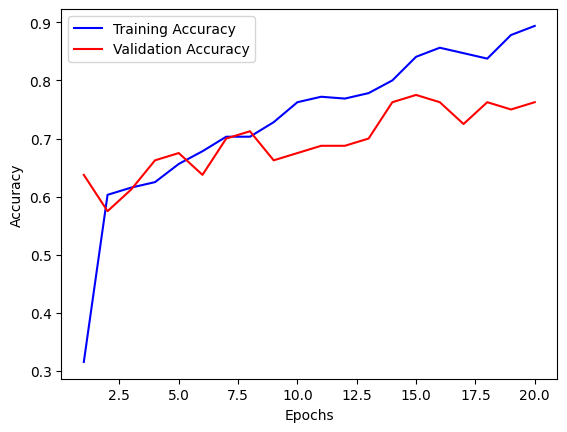

In [ ]:
# Plot evolution of accuracies throughout the training
###
# Axis labels
plt.xlabel('Epochs')
plt.ylabel('Accuracy')

# Training sample accuracy curve
plt.plot(np.arange(1 , 21, 1),
         training_history_lenet.history['accuracy'],
         label = 'Training Accuracy',
         color = 'blue')

# Test sample accuracy curve
plt.plot(np.arange(1 , 21, 1),
         training_history_lenet.history['val_accuracy'],
         label = 'Validation Accuracy',
         color = 'red')

# Legend display
plt.legend()

# Figure display
plt.show()

In [ ]:
# Model results
###
# make predictions of labels on x_test
test_pred = lenet.predict(X_test)
print("Shape of predictions:", test_pred.shape)
# 2 Dimensional matrix of 10k x 10 dimension

# apply argmax on predictions to obtain vectors of integeres
# choose axis = 1 to perform argmax on columns
test_pred_class = test_pred.argmax(axis = 1)
print("Shape of predictions after argmax:", test_pred_class.shape)
# 1 Dimensional Vector of 10k x 1 dimension

y_test_class = y_test.argmax(axis = 1)

# show classification report
print(metrics.classification_report(y_test_class, test_pred_class))

# Measure time
model1_time = (time.time() - start_time)/60

# Modelling Time
print("Model 1: --- %s minutes ---" % model1_time)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
Shape of predictions: (100, 4)
Shape of predictions after argmax: (100,)
              precision    recall  f1-score   support

           0       0.81      0.81      0.81        53
           1       0.46      0.40      0.43        15
           2       0.63      0.63      0.63        30
           3       0.50      1.00      0.67         2

    accuracy                           0.70       100
   macro avg       0.60      0.71      0.63       100
weighted avg       0.70      0.70      0.70       100

Model 1: --- 4.033604788780212 minutes ---


[[43  4  5  1]
 [ 3  6  6  0]
 [ 7  3 19  1]
 [ 0  0  0  2]]


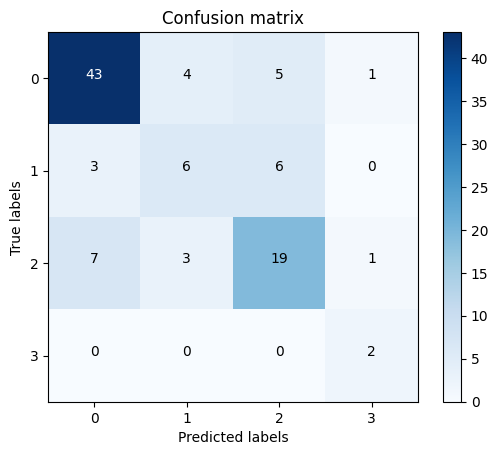

In [ ]:
# Show confusion matrix
cnf_matrix = metrics.confusion_matrix(y_test_class, test_pred_class)
print(cnf_matrix)

# Display a confusion matrix as a colored table
classes = range(0, 4)

plt.figure()

plt.imshow(cnf_matrix, interpolation='nearest',cmap='Blues')
plt.title("Confusion matrix")
plt.colorbar()
tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes)
plt.yticks(tick_marks, classes)

for i, j in itertools.product(range(cnf_matrix.shape[0]), range(cnf_matrix.shape[1])):
    plt.text(j, i, cnf_matrix[i, j],
             horizontalalignment="center",
             color="white" if cnf_matrix[i, j] > ( cnf_matrix.max() / 2) else "black")

plt.ylabel('True labels')
plt.xlabel('Predicted labels')
plt.show()
